In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Placement_Data_Full_Class.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1.0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2.0,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3.0,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4.0,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5.0,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
df.shape

(217, 15)

In [5]:
df.isnull().sum()
df["salary"] = df["salary"].fillna(0)
df = df.fillna(method="ffill")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7340\21040113.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [6]:
df[df["status"] == "Not Placed"].shape[0]

69

In [7]:
df[df["status"] == "Not Placed"].describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.0
mean,107.478261,57.209420,58.128986,61.652029,69.723913,61.371594,0.0
std,67.199135,8.496873,9.890057,6.960432,11.780642,5.794452,0.0
min,4.000000,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,46.000000,52.000000,50.000000,57.000000,60.000000,58.320000,0.0
50%,106.000000,56.000000,60.000000,61.000000,68.000000,60.640000,0.0
75%,170.000000,63.000000,64.000000,65.000000,76.000000,65.330000,0.0
max,215.000000,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


In [20]:
df[["salary","mba_p"]].corr()

,salary,mba_p
salary,1.000000,0.155249
mba_p,0.155249,1.000000


In [9]:
df.groupby("specialisation")["salary"].min()

specialisation
Mkt&Fin    0.0
Mkt&HR     0.0
Name: salary, dtype: float64

In [11]:
df[df["salary"] > 500000].shape[0]

3

In [12]:
stats.f_oneway(df["etest_p"], df["mba_p"])

F_onewayResult(statistic=np.float64(102.22508491163133), pvalue=np.float64(1.0350105328068027e-21))

In [13]:
science = df[df["degree_t"] == "Sci&Tech"]["salary"]
mhr = df[df["specialisation"] == "Mkt&HR"]["salary"]

stats.ttest_ind(science, mhr, nan_policy="omit")

TtestResult(statistic=np.float64(2.692041243555374), pvalue=np.float64(0.007897969943471179), df=np.float64(152.0))

In [14]:
salary = df["salary"]

z = (salary - salary.mean()) / salary.std()

z.head()

0    0.471090
1    0.020157
2    0.342252
3   -1.268223
4    1.469584
Name: salary, dtype: float64

In [15]:
mean = salary.mean()
std = salary.std()

stats.norm.cdf(900000, mean, std) - stats.norm.cdf(700000, mean, std)

np.float64(0.0005923786555792621)

In [16]:
science = df[df["degree_t"] == "Sci&Tech"]

stats.ttest_rel(science["etest_p"], science["mba_p"])

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.517920600505392e-06), df=np.int64(58))

In [17]:
science = df[df["degree_t"] == "Sci&Tech"]

stats.ttest_rel(science["etest_p"], science["mba_p"])

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.517920600505392e-06), df=np.int64(58))

In [18]:
df.corr(numeric_only=True)["salary"].sort_values(ascending=False)

salary      1.000000
ssc_p       0.547516
hsc_p       0.462441
degree_p    0.379896
etest_p     0.183617
mba_p       0.155249
sl_no       0.021418
Name: salary, dtype: float64

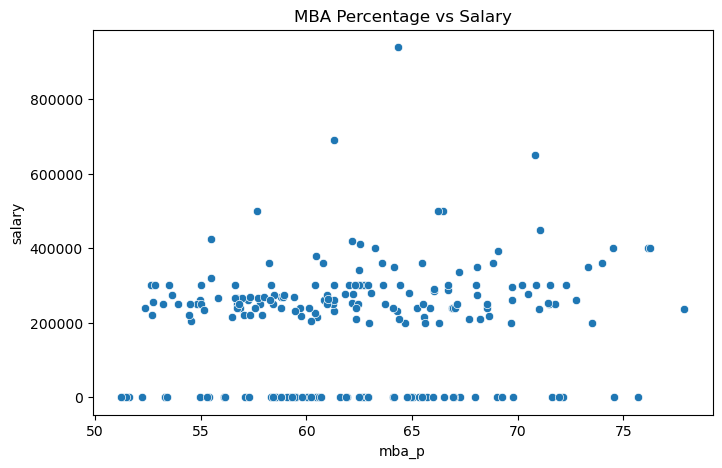

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="mba_p", y="salary")
plt.title("MBA Percentage vs Salary")
plt.show()